In [1]:
import sys
from tqdm import tqdm
sys.path.append("/mnt/Personal/Projects/Autofocus/Code/Universal")


In [2]:

import gpu_start # type: ignore
gpu_start.activate_gpu([3],print_details=False)

2026-03-03 02:09:56.232000: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772483996.251115  558714 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772483996.257120  558714 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772483996.272052  558714 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772483996.272074  558714 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772483996.272077  558714 computation_placer.cc:177] computation placer alr

GPU 0 VRAM limited to 3GB
Configured GPU 0: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU'}


I0000 00:00:1772484001.858574  558714 gpu_device.cc:2019] Created device /device:GPU:0 with 2168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1772484001.869116  558714 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --------------- some utility functions ---------------
cmap = 'viridis'

# image preprocessing
def input_img(path, default=224):
    image = tf.image.decode_png(tf.io.read_file(path))
    image = tf.cast(image, tf.float32)

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    # ---------- Step 1: make square ----------
    if h != w:
        max_side = tf.maximum(h, w)
        pad_h = max_side - h
        pad_w = max_side - w

        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        image = tf.pad(
            image,
            [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]], # type: ignore
            constant_values=0
        )

    # ---------- Step 2: resize or pad ----------
    new_size = tf.shape(image)[0]

    if new_size > default:
        image = tf.image.resize(image, [default, default])
    elif new_size < default:
        pad_total = default - new_size
        pad_top = pad_total // 2
        pad_bottom = pad_total - pad_top
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left

        image = tf.pad(
            image,
            [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]], # type: ignore
            constant_values=0
        )

    # ---------- Step 3: add batch ----------
    image = tf.expand_dims(image, axis=0)

    return image

# image normalization
def normalize_image(img):
    grads_norm = img[:,:,0]+ img[:,:,1]+ img[:,:,2]
    grads_norm = (grads_norm - tf.reduce_min(grads_norm))/ (tf.reduce_max(grads_norm)- tf.reduce_min(grads_norm))
    return grads_norm

    
# --------------- get the model ---------------

test_model = tf.keras.applications.resnet50.ResNet50()

In [12]:



def get_saliency_map(img, model):
    # load and preprocess image
    img = tf.keras.applications.densenet.preprocess_input(img)

    # forward pass
    preds = model(img)
    max_idx = tf.argmax(preds, axis=1)

    # compute gradients
    with tf.GradientTape() as tape:
        tape.watch(img)
        preds = model(img)
        max_score = preds[0, max_idx[0]]

    grads = tape.gradient(max_score, img)

    # return normalized saliency map and resized input
    saliency = normalize_image(grads[0])
    normal_img = normalize_image(img[0])

    return normal_img, saliency

def plot_images(img, normal_img, saliency, delta=0.5):
    
    plot1 = img/255.0
    plot2 = saliency
    # plot3 = saliency*delta+normal_img/delta
    plot3 = np.where(saliency<delta,0,(saliency-delta)*normal_img)
    
    plt.figure(figsize=(12, 5))
    plt.axis("off")

    plt.subplot(1, 3, 1)
    plt.imshow(plot1[0])
    plt.title("Org Image")

    plt.subplot(1, 3, 2)
    plt.imshow(plot2, cmap=cmap)
    plt.title("Saliency Map")
    
    plt.subplot(1, 3, 3)
    plt.imshow(plot3, cmap=cmap)
    plt.title("Overaly Map")

    plt.show()
    


100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


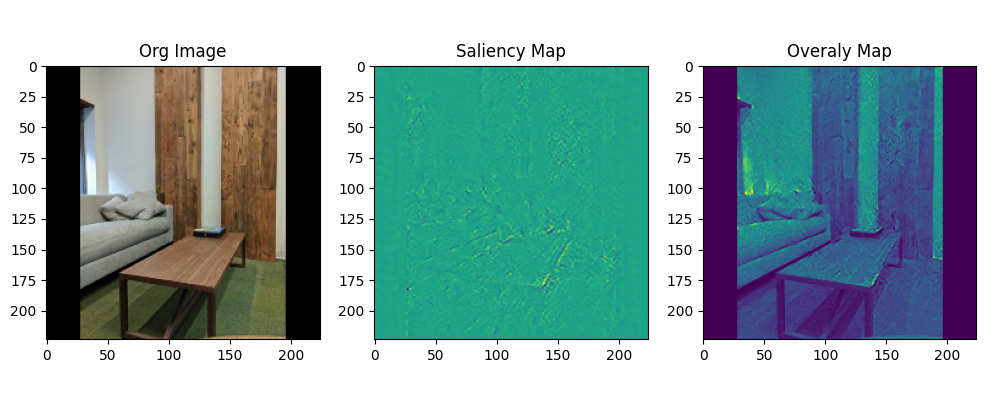

In [16]:
image_path = '/mnt/Personal/Projects/Autofocus/test_folder/sofa.jpg'
image_matrix = input_img(image_path)


normal=[]
sal=[]

for _ in tqdm(range(1)):
    normal_img, saliency = get_saliency_map(image_matrix, test_model)
    normal.append(normal_img)
    sal.append(saliency)
    

    
plot_images(image_matrix, normal[0], sal[0],delta=0.3)

# def matrix_range(mat):
#     print(mat.shape)
#     print(np.min(mat))
#     print(np.mean(mat))
#     print(np.max(mat))

# matrix_range(image_matrix)
# matrix_range(normal[0])
# matrix_range(sal[0])